# FireLands: Incorporating the effect of wildfires on sediment dynamics and landscape evolution

This notebook provides a brief introduction and user's guide to the **FireLands** Landscape Evolution model. FireLands combines a newly developed `WildfireGenerator` component with already existing erosion and deposition, and soil production components in Landlab. This notebook combines two documents, a User's Manual and a notebook-based example, written Matheus de Almeida to accompany the following publication:

* de Almeida, M., Shobe, C.M., Roda-Boluda, D.C., Gourbet, L., Veraverbeke, S., Distelbrink, A., Campforts, B. (2026) FireLands 1.0: A landscape evolution model for simulating the effects of fires and post-fire erosion on sediment dynamics in evolving landscapes. *in prep.*

## Background on WildfireGenerator component

The Landlab WildfireGenerator component is a cellular automaton that simulates landscape-scale fire activity driven by global climate-vegetation interactions. The WildfireGenerator is capable of simulating fire ignition and spread, fire severity and vegetation regrowth across two-dimensional model landscapes. 

WildfireGenerator simulates fire regimes by the interaction between fuel availability and aridity, keeping track of fire characteristics such as frequency, burned area, and severity. In FireLands, WildfireGenerator is coupled with components for fluvial incision and non-linear diffusion. Throughout this notebook, we will use the Landlab SpaceLargeScaleEroder and DepthDependentTaylorDiffuser components for that purpose. The user is motivated to check out the SpaceLargeScaleEroder and DepthDependentTaylorDiffuser notebooks ([see notebook on SpaceLargeScaleEroder](https://github.com/landlab/landlab/blob/master/docs/source/tutorials/landscape_evolution/space/SPACE_large_scale_eroder_user_guide_and_examples.ipynb) and [notebook on DepthDependentTaylorDiffuser](https://github.com/landlab/landlab/blob/master/docs/source/tutorials/hillslope_geomorphology/depth_dependent_taylor_diffuser/depth_dependent_taylor_diffuser.ipynb)).

Prerequisites: A working knowledge of the Python programming language (WildfireGenerator and Landlab support Python 3.x) as well as the NumPy and MatPlotLib libraries. Basic familiarity with the Landlab modeling toolkit (see Hobley et al., 2017 GMD, and Barnhart et al., 2020 eSurf) is recommended.

## Model description

### Input parameters

- **potential_fires** $Pot_i$: Number of potential fires per time step [-]. Default = 100. 
- **aridity** $a$: Dimensionless aridity index [-]. Default = 0.5. 
- **riv_min** $A_{fb}$: Drainage area threshold for firebreak rivers [L$^2$]. Default = 2e5. 
- **alpha** $\alpha$: Scaling factor to create a preference for the upslope spreading of the fire [-]. Default = 0.3.
- **sev_exponent** $\beta$: Exponent of the fire severity-aridity relationship (after Grunig et al. (2023)) [-]. Default = 0.64.

### Model fields 
Fields listed here are updated by the component at the grid locations listed. NOTE: because flow routing is handled by other Landlab components, fields such as `drainage_area` are not altered by the WildfireGenerator model and are not listed here but required to run the model.

- `fuel_availability`, node, [-]: Dimensionless fuel availability at every node.

### Model attributes
Other model attributes created upon model initiation and updated when executing run_one_step are: 
- `fire_log`: DataFrame with all the fire regimes characteristics. It is reset every time run_one_step function is called. `fire_log` contains the following columns:
    - `year`: The year in which every fire was triggered. 
    - `fire_size (km2)`: Extent of each fire in km$^2$. 
    - `center_X` and `center_Y`: Coordinates where the fire ignited. 
    - `severity_factor`: Severity of the fire (every fire will have a different severity).
    - `aridity`: Aridity value used as an input.
    - `changed_nodes`: List of nodes affected by each fire.
    - `pct_of_vegetation_removed`: Percentage of vegetation removed by that fire. A fire removes the same percentage of vegetation from every node affected by that fire. 


## Steps of the FireLands Landlab Landscape Evolution Model

Note: these steps are for a `WildfireGenerator` model that is coupled to the `SpaceLargeScaleEroder` and `DepthDependentTaylorDiffuser` Landlab components. To see examples of how to couple other Landlab components, please refer to the Landlab documentation: [http://landlab.github.io](http://landlab.github.io).

### Step 1: Import the necessary libraries 

The `WildfireGenerator`, `SpaceLargeScaleEroder`, `DepthDependentTaylorDiffuser` and `ExponentialWeatherer` components are required, as are the model grid component and a flow routing component. 

In addition to the relevant process components, some Landlab utilities are required to generate the model grid (in this example RasterModelGrid) and to visualize output (imshowhs_grid). Note that while it is possible to visualize output through functionality in other libraries (e.g., matplotlib), imshowhs_grid provides a simple way to generate 2-D maps of model variables.

Most Landlab functionality requires the Numpy package for scientific computing in python. The matplotlib plotting library has also been imported to aid visualization of results.

In [1]:
# Importing libraries
import numpy as np
import matplotlib.pyplot as plt 
from landlab import (RasterModelGrid, imshowhs_grid)

from landlab.components import (DepthDependentTaylorDiffuser,
                                ExponentialWeatherer,
                                SpaceLargeScaleEroder,
                                DepressionFinderAndRouter,
                                FlowAccumulator, 
                                WildfireGenerator)

from FireLands import (DiffusionChanger, ErosionChanger)

## Step 2: Create a synthetic landscape without fire activity 

For this example we will use a synthetic raster grid. In addition to using user-defined, synthetic model grids, it is also possible to import digital elevation models for use as a model domain (see the tutorial reading_dem_into_landlab). In this example, we create a synthetic, square model domain by creating an instance of the RasterModelGrid. The grid is composed of 50 rows and 50 columns for a total of 250 nodes, with user-defined spacing of 10m.

We will use `SpaceLargeScaleEroder`, `DepthDependentTaylorDiffuser`, and `ExponentialWeatherer` components to evolve the landscape to steady state. 

In [2]:
# Set grid parameters
num_rows = 50
num_columns = 50
node_spacing = 10

# track sediment flux at the node adjacent to the outlet at lower-left
node_next_to_outlet = num_columns + 1

# Instantiate model grid
mg = RasterModelGrid((num_rows, num_columns), node_spacing)
# add field ’topographic elevation’ to the grid
mg.add_zeros("topographic__elevation", at="node")
# set constant random seed for consistent topographic roughness
np.random.seed(seed=5000)

# Create initial model topography:
# plane tilted towards the lower−left corner
topo = mg.node_y / 100000.0 + mg.node_x / 100000.0

# add topographic roughness
random_noise = (
    np.random.rand(len(mg.node_y)) / 1000.0
)  # impose topography values on model grid
mg["node"]["topographic__elevation"] += topo + random_noise

# add field 'soil__depth' to the grid
mg.add_zeros("soil__depth", at="node")

# Set 0 m of initial soil depth at core nodes
mg.at_node["soil__depth"][mg.core_nodes] = 0  # meters

# Add field 'bedrock__elevation' to the grid
mg.add_zeros("bedrock__elevation", at="node")

# Sum 'soil__depth' and 'bedrock__elevation'
# to yield 'topographic elevation'
mg.at_node["bedrock__elevation"][:] = mg.at_node["topographic__elevation"]
mg.at_node["topographic__elevation"][:] += mg.at_node["soil__depth"]

### Step 2.1: Set boundary conditions

The user must determine the boundary conditions of the model domain (i.e., determine across which boundaries water and sediment may flow). Boundary conditions are controlled by setting the status of individual nodes or grid edges (see Hobley et al., 2017). Here, we use a single corner node as an “open” boundary and all other boundary nodes will be “closed”. We first use set closed boundaries at grid edges to ensure that no mass (water or sediment) may cross the model boundaries. Then, set watershed boundary condition outlet id is used to open (allow flow through) the lower-left corner of the model domain.

In [3]:
# Close all model boundary edges
mg.set_closed_boundaries_at_grid_edges(
    bottom_is_closed=True, left_is_closed=True, right_is_closed=True, top_is_closed=True
)

# Set lower-left (southwest) corner as an open boundary
mg.set_watershed_boundary_condition_outlet_id(
    0, mg["node"]["topographic__elevation"], -9999.0
)

### Step 2.2: Instantiate the components

Like most Landlab components, SpaceLargeScaleEroder, DepthDependentTaylorDiffuser, and ExponentialWeatherer are written as a Python classes. The class was imported at the beginning of the driver script (step 1). In this step, the user declares the instance of these classes and sets any relevant model parameters. At this point we do not yet make an instance of the WildfireGenerator component. 

In [4]:
# Instantiate flow router and depression finder and router
fr = FlowAccumulator(mg, flow_director="D8")

# Instantiate SPACE model with chosen parameters
sp = SpaceLargeScaleEroder(
    mg,
    K_sed=0.00015,
    K_br=0.0001,
    F_f=0.0,
    phi=0.0,
    H_star=1.0,
    v_s=0.001,
    m_sp=0.45,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

# Instantiate ExponentialWeatherer with chosen parameters
ew = ExponentialWeatherer(
    mg,
    soil_production_maximum_rate = 0.001,
    soil_production_decay_depth = 0.44)

# Instantiate DepthDependentTaylorDiffuser with chosen parameters
nld = DepthDependentTaylorDiffuser(
    mg,
    soil_transport_velocity = 0.001,
    slope_crit = 1.2,
    if_unstable ='warn')

### Step 2.3: Set clock parameters, array to store sediment fluxes at the outlet and run the loop 

The SpaceLargeScaleEroder component calculates sediment entrainment and deposition, bedrock erosion, and changes in land surface elevation over time. The DepthDependentDiffuser component calculates soil erosion and deposition through non-linear diffusion in land surface elevation over time. ExponentialWeatherer calculates soil production using an exponential relationship with soil thickness. The code shown below is an example of how to run these model over several model timesteps. 

In the example below, the simulation is run in a loop for a user-defined number of timesteps (`ndt_topo` in this step). The user is also responsible for choosing the model timestep (`dt_topo` here). Within the loop, the following steps occur:

1. Elevation is added to the model grid core nodes based on the user-defined uplift rate ($U$).
2. The flow router runs first to determine topographic slopes and water discharge at all nodes on the model domain.
3. The SpaceLargeScaleEroder model runs for the duration of a single timestep, computing sediment transport, bedrock erosion, and topographic surface evolution.
4. The DepthDependentDiffuser model runs for the duration of a single timestep, computing soil transport, deposition and topographic surface evolution.
5. ExponentialWeatherer computes the soil production rate from bedrock at every node according to the `soil__depth` field.
6. At each model iteration, values of sediment flux at the outlet are stored in an array called "sedflux".


In [5]:
# Set clock parameters 
dt_topo = 200                        # Timestep
runtime_topo = 1e6                   # Total runtime
ndt_topo = int(runtime_topo/dt_topo) # Number of timesteps

# Create empty array to fill with sediment flux and time values 
sedflux = np.zeros(ndt_topo)

# Define uplift rate U
U = 0.001 # m/yr

for i in range(ndt_topo):
    mg.at_node["bedrock__elevation"][mg.core_nodes] += U * dt_topo
    fr.run_one_step()
    sp.run_one_step(dt_topo)
    nld.run_one_step(dt_topo)
    ew.run_one_step()
    sedflux[i] = mg.at_node["sediment__flux"][node_next_to_outlet]
    

## Visualization of results
### Visualize sediment yeld through time, topography and soil depth

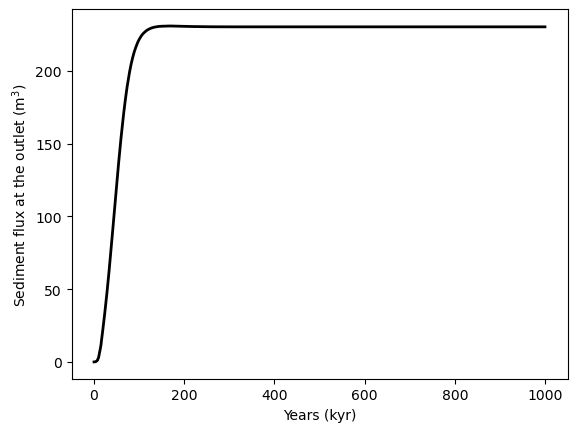

In [6]:
#Plot sediment flux through time to check whether the landscape is in steady state
plt.plot((np.arange(ndt_topo)*dt_topo)/1000, sedflux, color='black', lw=2)
plt.xlabel('Years (kyr)')
plt.ylabel('Sediment flux at the outlet (m$^3$)')
plt.show()

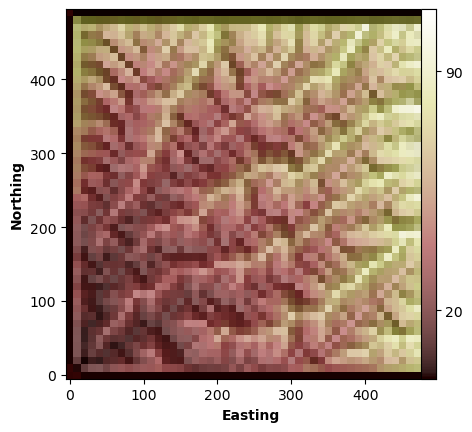

In [7]:
#Visualize our topography 
imshowhs_grid(
            mg,
            "topographic__elevation",
            ticks_km=False,
            colorbar_label_y=4,
            allow_colorbar=True,
            cbar_or="vertical",
            cbar_height="100%",
            cbar_width="4%",
            add_label_bbox=True,
        )
plt.show()

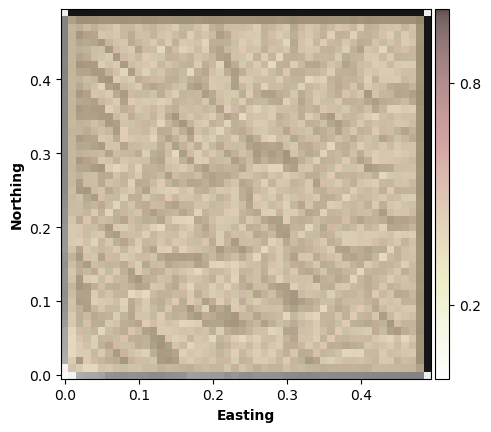

In [8]:
soils_prefire = mg.at_node['soil__depth'].copy()

# Visualize soil depth distribution 
imshowhs_grid(
            mg,
            "topographic__elevation",
            drape1=mg.at_node['soil__depth'],
            plot_type="Drape1",
            ticks_km=True,
            cmap='pink_r',
            alpha= 0.7, 
            shrink=0.80,
            colorbar_label_y=4,
            bbox_to_anchor=(0.05, 0, 1, 1),
            vmin=0,
            vmax=1,
            allow_colorbar=True,
            cbar_or="vertical",
            cbar_height="100%",
            cbar_width="4%",
            add_label_bbox=True,
        )
plt.show()

## Step 3: Incorporating fire activity in the landscape. 
To do that, we need to instantiate the WildfireGenerator component. WildfireGenerator requires a new field at the nodes called "fuel_availability". After creating the "fuel_availability" field, we need to evolve the vegetation to reach a dynamic equilibrium with fires. Let's define our clock parameters for this step and create the "fuel_availability" field. Additionally, WildfireGenerator uses `topographic__elevation` field to define firebreak nodes, which will not be burned by a fire.

In [9]:
#Defining new variables to run WildfireGenerator

# Timestep
dt_fire=1

# Total runtime
runtime_fire=200

# Number of timesteps
ndt_fire = int(runtime_fire/dt_fire)

fuel_status = np.empty(ndt_fire)

# Creating the fuel availability field and adding a reproducible random initial noise
veg = mg.add_zeros("node", "fuel_availability", clobber=True)
veg[:] = np.random.rand(mg.number_of_nodes)*0.75


### Step 3.1: Instantiate WildfireGenerator and run the loop (simulating only fires, no erosion yet)

In [10]:
#Instantiate WildfireGenerator and run a new loop simulating only fires
wg = WildfireGenerator(
    mg,
    potential_fires = 60,
    minimum_river_threshold=1e4,     
    aridity = 0.5,   # In this example we use intermediate aridity of 0.5 
)

#Run the loop (with WildfireGenerator only)
for it in range(ndt_fire):
    wg.run_one_step(dt_fire)

    fuel_status[it] = np.mean(mg.at_node['fuel_availability'])

## Visualization of results
### Fuel availability patterns

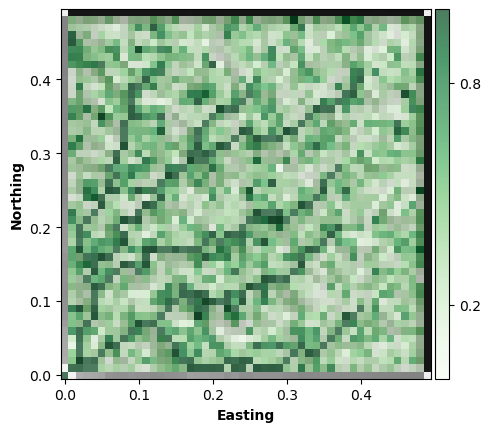

In [11]:
#Visualize the output vegetation pattern 
imshowhs_grid(
            mg,
            "topographic__elevation",
            drape1=mg.at_node['fuel_availability'],
            plot_type="Drape1",
            ticks_km=True,
            cmap='Greens',
            alpha= 0.7, 
            shrink=0.80,
            colorbar_label_y=4,
            bbox_to_anchor=(0.05, 0, 1, 1),
            vmin=0,
            vmax=1,
            allow_colorbar=True,
            cbar_or="vertical",
            cbar_height="100%",
            cbar_width="4%",
            add_label_bbox=True,
        )
plt.show()

### Mean fuel availability from initial condition to dynamic equilibrium

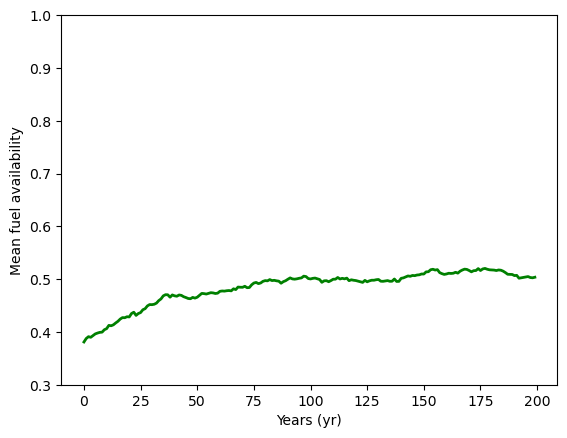

In [12]:
#Plot the mean fuel availability throughout the landscape
plt.plot((np.arange(ndt_fire)*dt_fire), fuel_status, color='green', lw=2)
plt.xlabel('Years (yr)')
plt.ylabel('Mean fuel availability')
plt.ylim([0.3,1])
plt.show()

## Step 4: Couple WildfireGenerator with SpaceLargeScaleEroder and DepthDependentTaylorDiffuser components

For this we use ErosionChanger and DiffusionChanger. These are python classes that calculate changes in erosion efficiency ($K_{sed}$ in SpaceLargeScaleEroder) and soil transport velocity ($D$ in DepthDependentTaylorDiffuser) based on the "fuel_availability" field. At a given point, the erosion parameters increase as "fuel_availability" decreases. For more information, see de Almeida et al. (2026, *in prep.*).  

In [13]:
# Instantiate ErosionChanger and DiffusionChanger

dt_flands = 1
runtime_flands = 100 
ndt_flands = int(runtime_flands/dt_flands)

Ec = ErosionChanger(mg,
                    K_sed0 = 0.00015,     # Initial "background" K_sed value
                    K_boost = 1e2)        # Maximum fold increase in K_sed

Dc = DiffusionChanger(mg,
                    diff_0 = 0.001,
                    diffusion_boost = 10)

sedflux_fire = np.empty(ndt_flands+1)

for it in range(ndt_flands+1):
    sedflux_fire[it] = mg.at_node["sediment__flux"][node_next_to_outlet]
    fr.run_one_step()
    wg.run_one_step(dt_flands)
    ew.run_one_step()
    nld.run_one_step(dt_flands)
    sp.run_one_step(dt_flands)
    Ec.run_one_step(sp,dt_flands)
    Dc.run_one_step(nld,dt_flands)
    

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

## Visualization of results
### Sediment thickness after 100 years of fire activity

In [ ]:
# Visualize soil thickness after 100 years of fire activity 
imshowhs_grid(
            mg,
            "topographic__elevation",
            drape1=mg.at_node['soil__depth'],
            plot_type="Drape1",
            ticks_km=True,
            cmap='pink_r',
            alpha= 0.7, 
            shrink=0.80,
            colorbar_label_y=4,
            bbox_to_anchor=(0.05, 0, 1, 1),
            vmin=0,
            vmax=1,
            allow_colorbar=True,
            cbar_or="vertical",
            cbar_height="100%",
            cbar_width="4%",
            add_label_bbox=True,
        )
plt.show()

### Sediment fluxes at the catchment outlet

In [ ]:
# Visualize changes in sediment fluxes with fire activity

#Plot sediment flux through time to check whether the landscape is in steady state
plt.plot(np.arange(ndt_flands+1), sedflux_fire, color='black', lw=2)
plt.xlabel('Years (kyr)')
plt.ylabel('Fire related sediment flux at the outlet (m$^3$)')
plt.show()